# Set up notebook

In [ ]:
import xarray as xr 
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

import importlib
import sys
util_files = '../util_files/'
sys.path.append(util_files)

import spec_utils_2d
importlib.reload(spec_utils_2d)



<module 'spec_utils_2d' from '/localhome/phymku/repo_for_paper/spectra/../util_files/spec_utils_2d.py'>

In [23]:
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00']

In [24]:
path_in="/CONUS_RR_PROCESSED_DATA/processed_data/maps/regridded/"
path_out_process='/CONUS_RR_PROCESSED_DATA/processed_data/spectra/h_spectra_1d/'

In [25]:
# Hanning window function

def create_window(ds_for_fft):
    
    # Get coordinates
    lat = ds_for_fft['lat']
    lon = ds_for_fft['lon']

    # Create a 2D window using outer product of 1D window functions
    window_1d = np.hanning(len(lat))  # 1D Hanning window
    window_2d = np.outer(window_1d, window_1d)  # Create 2D window

    ds_window = xr.DataArray(window_2d,dims=['lat','lon'],coords={'lon':lon,'lat':lat})
    
    return ds_window


# Calculate spectra

In [26]:
model_str_list_plot = ['_nonrr_']#,'_rr_']
date = '2010-06-01'
    
itime_list_plot = np.arange(0)
var_list_plot = ['w']#,'T']
lev_list_plot = ['300']#,'3.1','8.8e-3','5.3e-5']

In [27]:
#
# CONUS-RR
#

# N = 512 centered ~ grid center
dr_extent = 30
dr = 0.1 # map data resolution
xlimL = 245
xlimU = xlimL + dr_extent
ylimL = 22
ylimU = ylimL + dr_extent
N = dr_extent/dr
window = True


In [28]:
save_spec_1d = False

In [29]:
reference_lev_list = xr.open_dataset('../util_files/110lev_list.nc')

In [ ]:
importlib.reload(spec_utils_2d)

data_list = [] # Appends all data output to this file

for model_str in model_str_list_plot:
    for var in var_list_plot:
        for itime in itime_list_plot:
            for lev in lev_list_plot:
                ds_in = xr.open_mfdataset(path_in+f'{var}*{lev}*{model_str}*{date}*')
                ds_map = ds_in[var].isel(time=itime)
                
                print('\nIsolated time and height')
                
                ds_for_fft_temp = ds_map.sel(lon=slice(xlimL,xlimU),lat=slice(ylimL,ylimU))
                print('Isolated lat lon region')
                
                if window:
                    ds_window = create_window(ds_for_fft_temp)
                    ds_for_fft_windowed = ds_for_fft_temp*ds_window
                    ds_for_fft = ds_for_fft_windowed
                else:
                    ds_for_fft = ds_for_fft_temp
                
                ds_fft_sorted = spec_utils_2d.fft2_of_ds(ds_for_fft,dr_resolution=dr)
                print('FFT done')
                
                print('variable', var)
                print("usr_lev", f'{float(lev):.2e}')
                actual_lev = f'{reference_lev_list.sel(lev=float(lev), method='nearest').lev.values:.2e}'
                print("actual_lev", actual_lev)
                print('itime',itime)
                print('dr_extent',dr_extent)
                print('dr',dr)
                print('xlimL',f'{xlimL:.1f}')
                print('xlimU',f'{xlimU:.1f}')
                print('ylimL',f'{ylimL:.1f}')
                print('ylimU',f'{ylimU:.1f}') 
                print('N', N)
                print('window', window)
                print(f'variable min (pre window) {np.min(ds_for_fft_temp.values):.2f}')
                print(f'variable max {np.max(ds_for_fft.values):.2f}')
                print('log 10 min power |coeff|^2',np.min(ds_fft_sorted.values))
                print('log 10 max power |coeff|^2',np.max(np.log10(ds_fft_sorted.values)))
                # print(f'min power \|coeff\|$^2$',np.min(ds_fft_sorted.values))

                height = None
                ds_spec = spec_utils_2d.plot_spec(ds_for_fft,var,ds_fft_sorted,height, save_spec_1d)
                
                ds_spec_1d = xr.Dataset()
                ds_spec_1d['spec'] = spec_utils_2d.horizontal_wavenumber_spectrum_1d(ds_fft_sorted)
                ds_spec_1d['lev'] = actual_lev
                ds_spec_1d['time'] = ds_in['time'].isel(time=itime)
                ds_spec_1d = ds_spec_1d.assign_coords({'time':ds_spec_1d.time}).expand_dims('time') # create time dimension
                
                if save_spec_1d:
                    time_str=str(ds_map.time.dt.strftime('%Y-%m-%d_%H:%M:%S').values)
                    fname = f'{var}_{lev}hPa{model_str}h_spec_{time_str}.nc'
                    ds_spec_1d.to_netcdf(path_out+fname)


# Plot spectra

In [ ]:
path_in = 'CONUS_RR_PROCESSED_DATA/processed_data/spectra/h_spectra_1d/'
date='2010-06-01' # Date to plot, appears in filename
var='T' # Variable to plot, appears in filename
lev='3.1' # Pressure to plot, this appears in filename. Current options 2025-10-28: 300, 3.1, 8.8e-3, 5.3e-5

itime_indices_plot = np.arange(24) # Indices of time coordinate to plot

ds_nonrr = xr.open_mfdataset(path_in+f'{var}*{lev}*nonrr_*{date}*').isel(time=itime_indices_plot)
ds_rr = xr.open_mfdataset(path_in+f'{var}*{lev}*rr_*{date}*').isel(time=itime_indices_plot)

ds_nonrr_mean = ds_nonrr.mean(dim='time')
ds_rr_mean = ds_rr.mean(dim='time')

In [118]:
# plot parameters

mpl.rcParams['figure.figsize'] = (5.5,6)
mpl.rcParams['font.size'] = 16
ylimL = 1e0 # w: 5e-1, T: 2e1 Lower bound for y axis, upper bound set by y0 which sets position of theoretical lines
y0 = 1e9 # w: 1e5, T: 1e8 Reference value for plotting theoretical lines
ylimU = y0*2

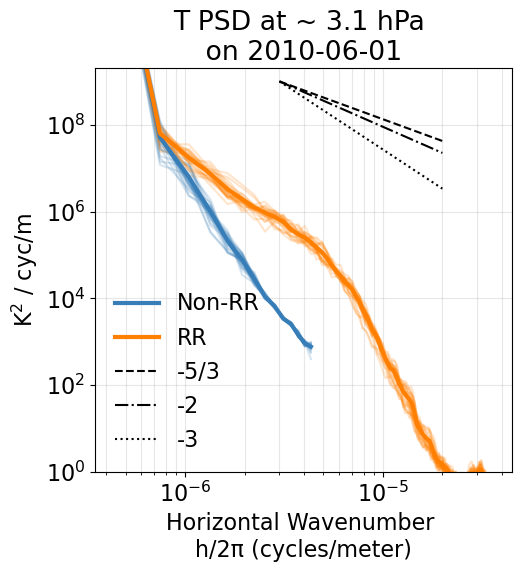

In [119]:
# --- Plot setup ---
fig, ax = plt.subplots()

h = ds_nonrr['h'].values[1:118] # Skip the first wavenumber as it has value 0

for time in ds_nonrr['time'].values:
    spec_nonrr = ds_nonrr['spec'].sel(time=time)[1:15].values # Limit to wavenumber 13 as this is Nyquist wavenumber for Non-RR data
    spec_rr = ds_rr['spec'].sel(time=time)[1:118].values # Limit wavenumber 117 as this is the Nyquist wavenumber for RR data
    
    ax.plot(h[:14], spec_nonrr, color=CB_color_cycle[0], alpha=0.2)
    ax.plot(h, spec_rr, color=CB_color_cycle[1], alpha=0.2)
    
ds_nonrr_mean['spec'][1:15].plot(ax=ax, color=CB_color_cycle[0], label='Non-RR', linewidth=3)
ds_rr_mean['spec'][1:118].plot(ax=ax, color=CB_color_cycle[1], label='RR', linewidth=3)

# --- Reference slopes ---
k_ref = np.logspace(np.log10(3e-6),np.log10(2e-5), 100)
ax.plot(k_ref, y0 * (k_ref / k_ref[0])**(-5/3), 'k--', label='-5/3')
ax.plot(k_ref, y0 * (k_ref / k_ref[0])**(-2), 'k-.', label='-2')
ax.plot(k_ref, y0 * (k_ref / k_ref[0])**(-3), 'k:', label='-3')

# --- Formatting ---
ax.set_xlim(3.5e-7,4.5e-5)
ax.set_ylim(ylimL,y0*2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Horizontal Wavenumber \nh/2π (cycles/meter)')
ax.set_ylabel('y label')
ax.set_title(f'Plot title')
ax.legend(frameon=False)
ax.grid(True,alpha=0.3,which='both')

# --- Labels ---
if var == 'w':
    ax.set_ylabel('m$^2$/s$^2$ / cyc/m')
    ax.set_title(f'w PSD at ~ {float(lev):.1f} hPa \n on {date} ')
    
if var == 'T':
    ax.set_ylabel('K$^2$ / cyc/m')
    ax.set_title(f'T PSD at ~ {float(lev):.1f} hPa \n on {date} ')

plt.tight_layout()
plt.show()
